# 02 - EDA Transacional do Dataset Unificado

## Objetivo

Realizar análise exploratória transacional sobre o dataset unificado do Instacart em nível `pedido-produto`.

Este notebook busca entender padrões de comportamento relacionados a usuários, pedidos, produtos, recompra, categorias e sazonalidade temporal. Os insights gerados aqui serão usados posteriormente para orientar a etapa de feature engineering e a construção do dataset de modelagem.

Este notebook cobre:

- Análise geral de volume de usuários, pedidos, produtos, aisles e departments.
- Distribuição de pedidos por usuário.
- Distribuição de itens por pedido.
- Análise de produtos, aisles e departments mais frequentes.
- Análise de recompra geral e por diferentes dimensões.
- Análise temporal por dia da semana, hora do dia e intervalo entre pedidos.
- Comparação exploratória entre os conjuntos `prior` e `train`.
- Consolidação de insights para etapas futuras de feature engineering, baseline e modelagem.

## Inputs

- `data/processed/orders_product_unified.parquet`

A amostra auxiliar abaixo pode ser usada somente para desenvolvimento rápido de visualizações e validação de código:

- `data/test_sample/orders_product_sample.parquet`

## Outputs esperados

- Estatísticas descritivas do dataset transacional unificado.
- Tabelas e visualizações exploratórias sobre usuários, pedidos, produtos, categorias, recompra e padrões temporais.
- Identificação de comportamentos relevantes para recomendação de produtos.
- Registro dos principais insights para orientar os próximos notebooks:
  - Feature engineering.
  - Construção do dataset de modelagem em nível `user_id-product_id`.
  - Definição de baselines.
  - Experimentos com modelos.

## Limites deste notebook

Este notebook é apenas uma análise exploratória transacional.

Ele não constrói o dataset final de modelagem em nível `user_id-product_id`.

Ele não define split final de treino e validação.

Ele não define estratégia final de candidatos.

Ele não treina modelos.

Ele não implementa baselines.

As conclusões analíticas devem ser feitas usando o dataset completo em `data/processed/orders_product_unified.parquet`.

A amostra em `data/test_sample/orders_product_sample.parquet` deve ser usada apenas para acelerar o desenvolvimento de código e visualizações, sem embasar conclusões finais.

---

## 1. Setup inicial

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração de visualização
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TEST_SAMPLE_DIR = DATA_DIR / "test_sample"

UNIFIED_DATASET_PATH = PROCESSED_DIR / "orders_product_unified.parquet"
SAMPLE_DATASET_PATH = TEST_SAMPLE_DIR / "orders_product_sample.parquet"

assert UNIFIED_DATASET_PATH.exists(), (
    f"Dataset completo não encontrado em: {UNIFIED_DATASET_PATH}"
)

if not SAMPLE_DATASET_PATH.exists():
    print(f"Amostra auxiliar não encontrada em: {SAMPLE_DATASET_PATH}")
    
print("Arquivos encontrados com sucesso!")

Arquivos encontrados com sucesso!


### 1.1 Carregamento dos dados

In [3]:
USE_SAMPLE = False

dataset_path = SAMPLE_DATASET_PATH if USE_SAMPLE else UNIFIED_DATASET_PATH

df = pd.read_parquet(dataset_path)

print(f"Dataset carregado: {dataset_path}")
print(f"Shape: {df.shape[0]:,} linhas X {df.shape[1]:,} colunas")

if USE_SAMPLE:
    print(
        "⚠️​⚠️​ATENÇÃO: a amostra auxiliar está carregada.⚠️​⚠️​ "
        "⚠️​⚠️​Não use este resultado para conclusões analíticas finais.⚠️​⚠️​"
    )

Dataset carregado: /Users/helio/Library/CloudStorage/OneDrive-Pessoal/Pos_FIAP/Tech_Challanges/Fase2-Big-Data-Architecture/mlp-market-recommender-system/data/processed/orders_product_unified.parquet
Shape: 33,819,106 linhas X 15 colunas


In [4]:
sample = pd.read_parquet(SAMPLE_DATASET_PATH)

print(sample.shape)

(100000, 15)


---

## 2. Inspeções iniciais

**Objetivo**: Validar a estrutura do dataset antes da análise exploratória.

### 2.1 Visualização inicial

In [5]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0000,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0000,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0000,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0000,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0000,Natural Sweetener,17,13,baking ingredients,pantry


In [6]:
df.sample(5, random_state = 42)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
7009614,740068,21616,16,0,172941,prior,25,1,12,6.0000,Organic Baby Arugula,123,4,packaged vegetables fruits,produce
12886293,1360271,35503,5,1,5215,prior,3,3,13,20.0000,Organic Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs
30444410,3211401,5819,13,1,113114,prior,33,6,11,4.0000,Baby Carrots,123,4,packaged vegetables fruits,produce
27795025,2931112,9387,3,0,138407,prior,1,1,20,NaN,Granny Smith Apples,24,4,fresh fruits,produce
10883987,1149035,8277,3,1,78836,prior,9,4,10,3.0000,Apple Honeycrisp Organic,24,4,fresh fruits,produce


### 2.2 Estrutura do dataset e estatísticas descritivas

In [7]:
df.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  aisle                   object 
 14  department              object 
dtypes: float64(1), int64(10), object(4)
memory usage: 10.6 GB


In [8]:
df.describe(include = np.number)

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,"33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","31,741,038.0000","33,819,106.0000","33,819,106.0000"
mean,"1,710,566.2909","25,575.5145",8.3677,0.5901,"102,944.4265",17.1400,2.7373,13.4312,11.3642,71.2180,9.9185
std,"987,400.7619","14,097.6968",7.1395,0.4918,"59,467.3340",17.4983,2.0933,4.2461,8.9405,38.1990,6.2817
min,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
25%,"855,413.0000","13,519.0000",3.0000,0.0000,"51,435.0000",5.0000,1.0000,10.0000,5.0000,31.0000,4.0000
50%,"1,710,660.0000","25,256.0000",6.0000,1.0000,"102,626.0000",11.0000,3.0000,13.0000,8.0000,83.0000,9.0000
75%,"2,565,587.0000","37,935.0000",11.0000,1.0000,"154,412.0000",24.0000,5.0000,16.0000,15.0000,107.0000,16.0000
max,"3,421,083.0000","49,688.0000",145.0000,1.0000,"206,209.0000",100.0000,6.0000,23.0000,30.0000,134.0000,21.0000


In [9]:
df.describe(exclude = np.number)

,eval_set,product_name,aisle,department
count,33819106,33819106,33819106,33819106
unique,2,49685,134,21
top,prior,Banana,fresh fruits,produce
freq,32434489,491291,3792661,9888378


### 2.3 Inspeção dos valores nulos

In [10]:
missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending = False)
    .to_frame('missing_count')
)

missing_values['missing_pct'] = 100 * ( missing_values['missing_count'] / len(df))

missing_values

,missing_count,missing_pct
days_since_prior_order,2078068,6.1447
order_id,0,0.0000
product_id,0,0.0000
add_to_cart_order,0,0.0000
reordered,0,0.0000
user_id,0,0.0000
eval_set,0,0.0000
order_number,0,0.0000
order_dow,0,0.0000
order_hour_of_day,0,0.0000


A coluna `days_since_prior_order` pode conter valores nulos porque é o primeiro pedido conhecido de cada usuário e não possui um pedido anterior para calcular o intervalo.

Nesta etapa, os valores ausentes serão apenas identificados. A decisão de tratamento, como imputação, criação de flags ou exclusão, será tomada futuramente na etapa de **feature engineering**.

---

## 3. Entendimento transacional do dataset

**Objetivo**: Analisar o comportamento transacional presente no dataset unificado.

As análises buscam responder como usuários, pedidos, produtos, categorias, recompra e padrões temporais se comportam historicamente. Esses achados serão usados posteriormente para orientar a etapa de feature engineering e a construção do dataset de modelagem.

### 3.1 Visão geral do problema transacional

**Pergunta analítica**: Qual é a escala do problema de recomendação e como o volume está distribuído entre `prior` e `train`?

**Objetivo**: Consolidar uma visão executiva do dataset em termos de usuários, pedidos, produtos, categorias e itens por pedido.

In [11]:
overview_counts = pd.Series(
    {
        "rows": len(df),
        "users": df['user_id'].nunique(),
        "orders": df['order_id'].nunique(),
        "products": df['product_id'].nunique(),
        "aisles": df['aisle_id'].nunique(),
        "departments": df['department_id'].nunique()
    },
    name = "count",
).to_frame()

overview_counts

,count
rows,33819106
users,206209
orders,3346083
products,49685
aisles,134
departments,21


In [12]:
eval_set_summary = (
    df.groupby("eval_set")
    .agg(
        rows=("order_id", "size"),
        orders=("order_id", "nunique"),
        users=("user_id", "nunique"),
        products=("product_id", "nunique"),
        reordered_rate=("reordered", "mean"),
    )
    .assign(
        rows_pct=lambda data: 100 * data["rows"] / data["rows"].sum(),
        orders_pct=lambda data: 100 * data["orders"] / data["orders"].sum(),
        items_per_order=lambda data: data["rows"] / data["orders"],
    )
    .reset_index()
)

eval_set_summary.style.format(
    {
        "rows": "{:,.0f}",
        "orders": "{:,.0f}",
        "users": "{:,.0f}",
        "products": "{:,.0f}",
        "reordered_rate": "{:.2%}",
        "rows_pct": "{:.2f}%",
        "orders_pct": "{:.2f}%",
        "items_per_order": "{:.2f}",
    }
)

,eval_set,rows,orders,users,products,reordered_rate,rows_pct,orders_pct,items_per_order
0,prior,"32,434,489","3,214,874","206,209","49,677",58.97%,95.91%,96.08%,10.09
1,train,"1,384,617","131,209","131,209","39,123",59.86%,4.09%,3.92%,10.55


### 3.2 Comportamento dos usuários

**Pergunta analítica**: Os usuários possuem histórico suficiente para personalização?

**Objetivo**: Analisar a quantidade de pedidos disponíveis por usuário para entender a profundidade histórica do dataset.

Usuários com mais pedidos tendem a fornecer mais sinais comportamentais para recomendação personalizada. Já usuários com poucos pedidos podem ter pouco histórico para gerar features robustas, o que pode exigir cuidados futuros com fallback ou estratégias de cold start.

In [13]:
prior_user_order_counts = (
    df.loc[df["eval_set"] == "prior", ["user_id", "order_id"]]
    .drop_duplicates()
    .groupby("user_id")
    .agg(prior_order_count=("order_id", "count"))
    .reset_index()
)
prior_user_order_counts.head()

,user_id,prior_order_count
0,1,10
1,2,14
2,3,12
3,4,5
4,5,4


In [14]:
prior_user_order_counts["prior_order_count"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   206,209.0000
mean         15.5904
std          16.6548
min           3.0000
1%            3.0000
5%            3.0000
10%           3.0000
25%           5.0000
50%           9.0000
75%          19.0000
90%          37.0000
95%          51.0000
99%          88.0000
max          99.0000
Name: prior_order_count, dtype: float64

In [15]:
prior_user_order_counts["history_segment"] = pd.cut(
    prior_user_order_counts["prior_order_count"],
    bins=[0, 3, 6, 9, 15, 30, np.inf],
    labels=[
        "1-3 pedidos",
        "4-6 pedidos",
        "7-9 pedidos",
        "10-15 pedidos",
        "16-30 pedidos",
        "31+ pedidos",
    ],
)

history_segment_summary = (
    prior_user_order_counts["history_segment"]
    .value_counts(sort=False)
    .rename_axis("history_segment")
    .reset_index(name="users")
)

history_segment_summary["users_pct"] = (
    100 * history_segment_summary["users"] / history_segment_summary["users"].sum()
)

history_segment_summary

,history_segment,users,users_pct
0,1-3 pedidos,23986,11.6319
1,4-6 pedidos,49605,24.0557
2,7-9 pedidos,30922,14.9955
3,10-15 pedidos,36400,17.6520
4,16-30 pedidos,37587,18.2276
5,31+ pedidos,27709,13.4373


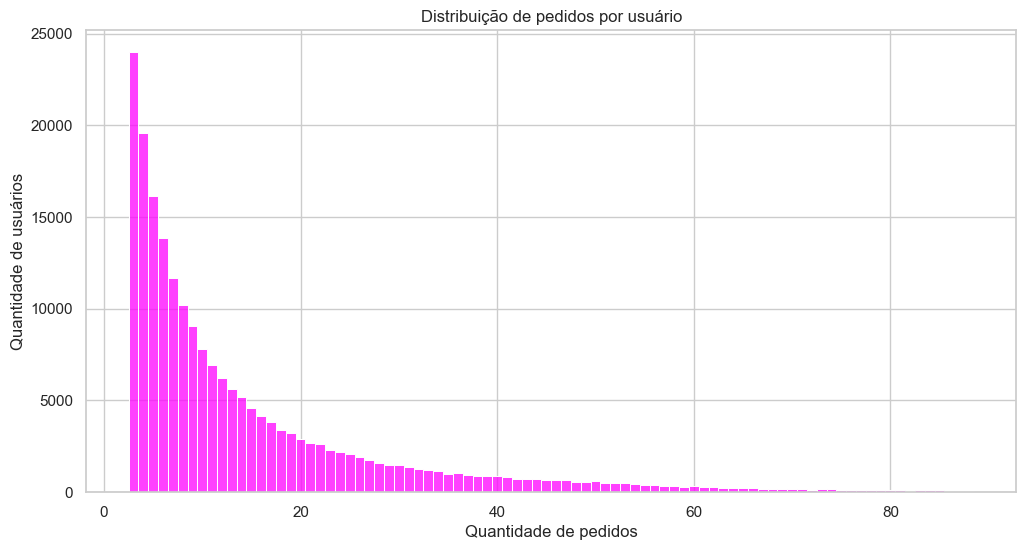

In [24]:
upper_limit = prior_user_order_counts["prior_order_count"].quantile(0.99)

sns.histplot(
    data=prior_user_order_counts[
        prior_user_order_counts["prior_order_count"] <= upper_limit
        ],
    x="prior_order_count",
    discrete = True,
    color = 'magenta'
)

plt.title("Distribuição de pedidos por usuário")
plt.xlabel("Quantidade de pedidos")
plt.ylabel("Quantidade de usuários")
plt.show()

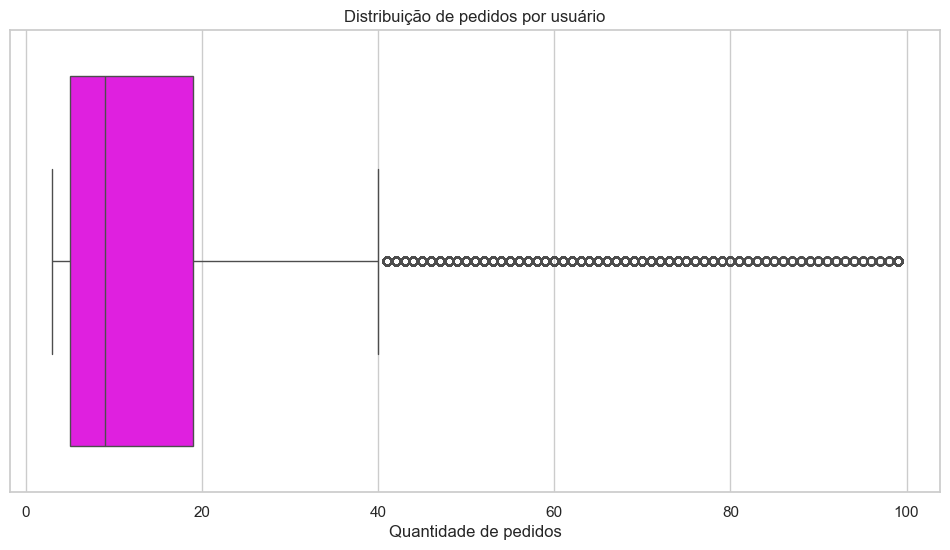

In [17]:
sns.boxplot(
    data=prior_user_order_counts,
    x="prior_order_count",
    color = 'magenta',
)

plt.title("Distribuição de pedidos por usuário")
plt.xlabel("Quantidade de pedidos")
plt.show()

**Leituras a partir dos resultados**

- A distribuição de pedidos por usuário é assimétrica à direita: muitos usuários concentram-se em faixas menores de histórico, enquanto uma parcela menor possui quantidade bem maior de pedidos.
- Os valores extremos parecem representar usuários com alto engajamento, não necessariamente inconsistências.
- Apesar dessa concentração inicial, mais da metade dos usuários possui pelo menos 9 pedidos no histórico, o que indica uma base razoável para capturar preferências recorrentes.
- Usuários com poucos pedidos ainda podem gerar features menos estáveis, especialmente para sinais de recompra e frequência.

**Ações para Feature Engineering**

- Criar uma feature simples de profundidade histórica do usuário, como `user_prior_order_count`.
- Avaliar uma feature de comportamento médio de compra, como `user_avg_basket_size`.
- Avaliar uma feature de frequência/ritmo de compra, calculada sem usar o pedido alvo.
- Considerar segmentar usuários por faixas de histórico apenas para análise e diagnóstico, não necessariamente como feature inicial.
- Não remover usuários com muitos pedidos apenas por serem outliers; eles representam comportamento válido de alto engajamento.

### 3.3 Comportamento dos pedidos

**Pergunta analítica**: Como os carrinhos se comportam em tamanho e variabilidade?

**Objetivo**: Analisar a quantidade de itens por pedido para entender o tamanho típico dos carrinhos, a presença de pedidos muito pequenos ou muito grandes e possíveis diferenças entre os conjuntos `prior` e `train`.

O tamanho do carrinho é relevante para recomendação porque ajuda a entender quantos produtos os usuários costumam comprar por pedido e pode influenciar tanto features futuras quanto a escolha de métricas `@K`.

In [18]:
prior_order_item_counts = (
    df.loc[df["eval_set"] == "prior"]
    .groupby(["order_id", "user_id"])
    .agg(
        items_per_order=("product_id", "count")
        )
    .reset_index()
)

prior_order_item_counts.head()

,order_id,user_id,items_per_order
0,2,202279,9
1,3,205970,8
2,4,178520,13
3,5,156122,26
4,6,22352,3


In [19]:
prior_order_item_counts["items_per_order"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)


count   3,214,874.0000
mean           10.0889
std             7.5254
min             1.0000
1%              1.0000
5%              2.0000
10%             2.0000
25%             5.0000
50%             8.0000
75%            14.0000
90%            20.0000
95%            25.0000
99%            35.0000
max           145.0000
Name: items_per_order, dtype: float64

In [20]:
prior_order_item_counts["basket_size_segment"] = pd.cut(
    prior_order_item_counts["items_per_order"],
    bins=[0, 3, 6, 10, 15, 25, np.inf],
    labels=[
        "1-3 itens",
        "4-6 itens",
        "7-10 itens",
        "11-15 itens",
        "16-25 itens",
        "26+ itens",
    ],
)

basket_size_summary = (
    prior_order_item_counts["basket_size_segment"]
    .value_counts(sort=False)
    .rename_axis("basket_size_segment")
    .reset_index(name="orders")
)

basket_size_summary["orders_pct"] = (
    100 * basket_size_summary["orders"] / basket_size_summary["orders"].sum()
)

basket_size_summary

,basket_size_segment,orders,orders_pct
0,1-3 itens,550768,17.1319
1,4-6 itens,678086,21.0921
2,7-10 itens,773277,24.0531
3,11-15 itens,591239,18.3907
4,16-25 itens,478675,14.8894
5,26+ itens,142829,4.4428


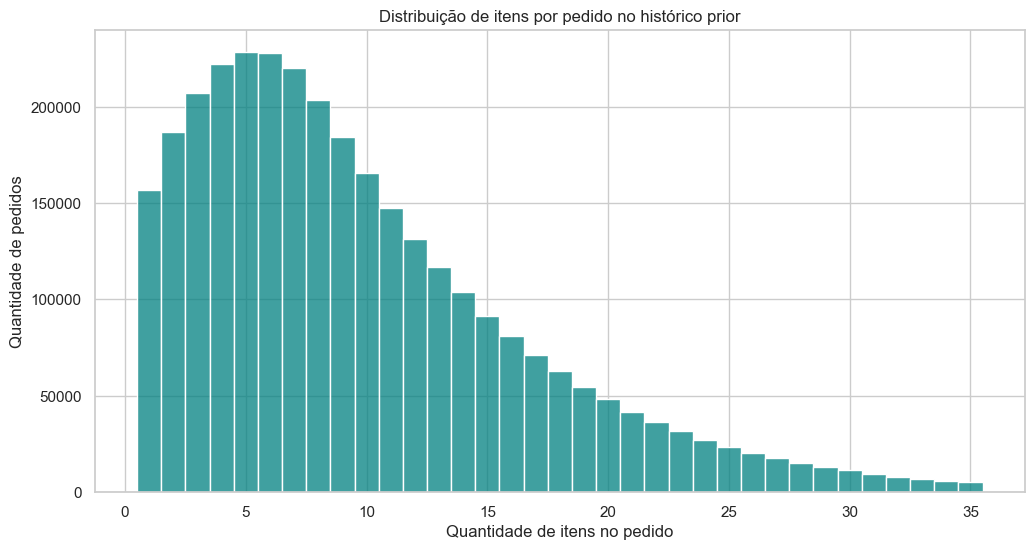

In [23]:
upper_limit = prior_order_item_counts["items_per_order"].quantile(0.99)

sns.histplot(
    data=prior_order_item_counts[
        prior_order_item_counts["items_per_order"] <= upper_limit
    ],
    x="items_per_order",
    discrete = True,
    color="teal",
)

plt.title("Distribuição de itens por pedido no histórico prior")
plt.xlabel("Quantidade de itens no pedido")
plt.ylabel("Quantidade de pedidos")
plt.show()

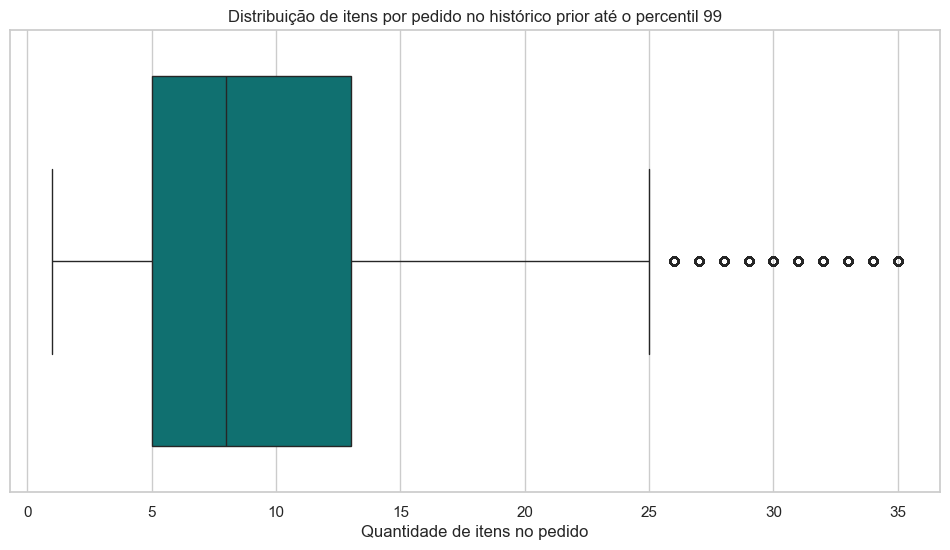

In [22]:
sns.boxplot(
    data=prior_order_item_counts[
        prior_order_item_counts["items_per_order"] <= upper_limit
    ],
    x="items_per_order",
    color="teal",
)

plt.title("Distribuição de itens por pedido no histórico prior até o percentil 99")
plt.xlabel("Quantidade de itens no pedido")
plt.show()

**Leituras a partir dos resultados**

- Os pedidos do histórico `prior` possuem em média aproximadamente 10 itens, enquanto a mediana é 8 itens. Isso indica que a média é puxada para cima por pedidos maiores.
- Metade dos pedidos possui até 8 itens, e 75% dos pedidos possuem até 14 itens, mostrando que a maior parte dos carrinhos está concentrada em tamanhos moderados.
- A distribuição é assimétrica à direita: existem pedidos muito grandes, chegando a 145 itens, mas eles representam uma parcela pequena da base.
- O percentil 99 é de 35 itens, indicando que pedidos acima desse valor são extremos em relação ao comportamento típico.
- Os pedidos extremos parecem representar carrinhos grandes reais, não necessariamente inconsistências, portanto não devem ser removidos automaticamente no EDA.

**Ações para Feature Engineering**

- Avaliar a criação de uma feature histórica de tamanho médio do carrinho por usuário, como `user_avg_basket_size`.
- Considerar também uma versão mais robusta, como mediana de itens por pedido, caso a média seja muito influenciada por carrinhos extremos.
- Não remover pedidos grandes automaticamente; primeiro avaliar impacto em features e métricas futuras.
- Usar o tamanho típico dos carrinhos como referência na definição futura de métricas `@K`, já que um `K` muito baixo pode não representar bem pedidos com muitos itens.